<a href="https://colab.research.google.com/github/maheenrazza/VAE-GANs/blob/main/26100337_PA3_1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<span style="color: #87CEEB;"> CS437/CS5317/EE414/EE513 Deep Learning Programming Assignment 3 Part-1B</span>**

# <span style="color: #9370DB;">**Submission Guidelines**</span>

- <span style="color: #9370DB;">Please rename the file to `<RollNumber>_PA3_1B`.</span>
- <span style="color: #9370DB;">Please also submit a **.py** file of every Notebook. You can do this by exporting your **ipynb** to a Python script.</span>
- <span style="color: #9370DB;">Please submit a zipped folder of both your Jupyter Notebooks and Python script files.</span>
- <span style="color: #9370DB;">PLEASE RUN ALL CELLS 🙏🏻.</span>




### Name: Maheen Raza

---


### Roll Number: 26100337

# GANs with Latent space interpolation

In this part of the assignment, you'll implement a Generative Adversarial Network (GAN) to:
- Generate images resembling handwritten digits from the MNIST dataset.
- Explore latent space interpolation between two images by transioning from one digit to another.
- Generate a few images of your own and perform some mathematical operations with them in the latent space to see what sort of output you can come up with.

[All code blocks should already have been run and the outputs should be visible in order to be graded]

### Imports

In [1]:
# ============ Import stuff here =============
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# for reproducibility
torch.manual_seed(42)
np.random.seed(42)
# ===== you may include more helper libs ======
# ===== (just don't include an entire =========
# ===== generator/discriminator - that ========
# ===== you've to make from scratch) ==========

Using device: cuda


### Load the MNIST thing

In this section:
- Load the MNIST dataset
- Transform/pre-process the dataset (if required)
- Define your test-train split
- Use dataloader to load stuff
- Print the split ratio AND visualize some of the digits (along with the labels)

In [ ]:
# Transform MNIST images to tensor and normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load full training set
full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Train-test split
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Dataloaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print split ratio
print(f"Total samples: {len(full_dataset)}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Split ratio: {len(train_dataset)/len(full_dataset):.2f} : {len(test_dataset)/len(full_dataset):.2f}")

Total samples: 60000
Train samples: 48000
Test samples: 12000
Split ratio: 0.80 : 0.20


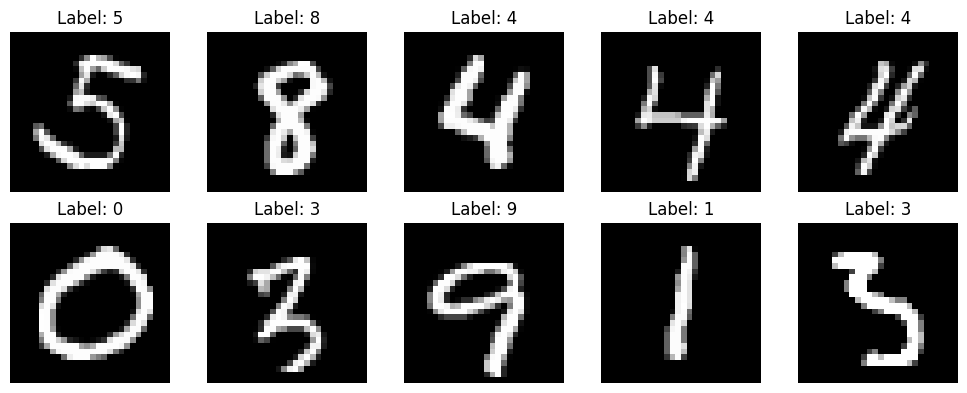

In [ ]:
# Visualize some digits with labels
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    img = images[i].squeeze().numpy()
    img = img * 0.5 + 0.5  # denormalize from [-1,1] to [0,1]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Make your GANg
![pic.png](attachment:pic.png)

Basic GAN structure is show above. GANs have two componenets:

**Generator (G):** Takes a random noise vector ($z$) as input and generates synthetic image $G(z)$ i.e., an output that aims to resemble real data.
**Discriminator (D):** Acts as a binary classifier that distinguishes between real and fake image. It is trained to correctly identify whether an input is real (from the dataset) or fake (generated by G).

They both compete with each other. The generator tries to fool the discriminator, while the discriminator tries to improve its ability to detect fakes. This adversarial process helps the generator produce increasingly realistic outputs.

In [ ]:
latent_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# initializing the instances of the Generator and Discriminator respectively
generator = Generator().to(device)
discriminator = Discriminator().to(device)

### Losses and optimizers

In [ ]:
# Loss
criterion = nn.BCELoss()

# Optimizers
#optimizer_g = optim.Adam(generator.parameters(), lr=0.0002)
#optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002)

optimizer_g = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## Training Loop
Now we have to load the data (preprocess it or do some image augmentation if you need) and train the model.

Lets have brief look at how the loop for a vanilla GAN looks like, and then you can implement it yourself.

Each epoch involves a couple of steps:
1. Prep some data both fake and real
2. Train the discriminator with some real data (real loss)
3. Train the discriminator with some fake data (fake loss)
4. Train the generator (generator loss)

details about losses is below

**Discriminator**
The discriminator is trained to distinguish between real and fake images (binary classification). It aims to correctly classify real images as real and generated images as fake. It has two components:
- Real Loss: Measures how well the discriminator classifies real images correctly.
- Fake Loss: Measures how well the discriminator identifies fake images. <br> <br>
The total discriminator loss is given by: <br>
$ L_{D} =$ real loss $+$ fake loss <br>
where <br>
real loss $= E_{x}\log(D(x))$ <br>
fake loss $= E_{z}\log(1-D(G(z)))$


**Generator**
The generator tries to fool the discriminator by generating images that D misclassifies as real. Instead of minimizing the difference between generated and real images directly, G is trained to maximize the likelihood that $D$ assigns high probability to fake images (so it'll only have the maximizing portion) <br><br>
$ L_{G} = E\log(D(G(z)))$  <br>

In [ ]:
# training settings
epochs = 50
rollnumber = "26100337"

gen_losses = []
disc_losses = []

best_g_loss = float('inf')
best_d_loss = float('inf')

for epoch in range(epochs):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        batch_size_curr = real_imgs.size(0)

        # flatten real images
        real_imgs_flat = real_imgs.view(batch_size_curr, -1)

        # labels
        real_labels = torch.ones(batch_size_curr, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size_curr, 1).to(device)

        # =========================
        # Train Discriminator
        # =========================
        optimizer_d.zero_grad()

        # real loss
        real_preds = discriminator(real_imgs_flat)
        d_real_loss = criterion(real_preds, real_labels)

        # fake loss
        z = torch.randn(batch_size_curr, latent_dim).to(device)
        fake_imgs = generator(z)
        fake_preds = discriminator(fake_imgs.detach())
        d_fake_loss = criterion(fake_preds, fake_labels)

        # total discriminator loss
        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizer_d.step()

        # =========================
        # Train Generator
        # =========================
        optimizer_g.zero_grad()

        z = torch.randn(batch_size_curr, latent_dim).to(device)
        generated_imgs = generator(z)
        preds = discriminator(generated_imgs)

        # generator wants discriminator to think fakes are real
        g_loss = criterion(preds, real_labels)
        g_loss.backward()
        optimizer_g.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    avg_d_loss = epoch_d_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / len(train_loader)

    disc_losses.append(avg_d_loss)
    gen_losses.append(avg_g_loss)

    print(f"Epoch [{epoch+1}/{epochs}], D Loss: {avg_d_loss:.4f}, G Loss: {avg_g_loss:.4f}")

    # save best generator
    if avg_g_loss < best_g_loss:
        best_g_loss = avg_g_loss
        torch.save(generator.state_dict(), f"{rollnumber}_gen.pth")

    # save best discriminator
    if avg_d_loss < best_d_loss:
        best_d_loss = avg_d_loss
        torch.save(discriminator.state_dict(), f"{rollnumber}_disc.pth")

print("Training complete.")
print(f"Best generator saved as: {rollnumber}_gen.pth")
print(f"Best discriminator saved as: {rollnumber}_disc.pth")

Epoch [1/50], D Loss: 1.2606, G Loss: 0.9804
Epoch [2/50], D Loss: 1.1867, G Loss: 1.1781
Epoch [3/50], D Loss: 1.1759, G Loss: 1.2722
Epoch [4/50], D Loss: 1.1804, G Loss: 1.2884
Epoch [5/50], D Loss: 1.1948, G Loss: 1.2528
Epoch [6/50], D Loss: 1.1967, G Loss: 1.2403
Epoch [7/50], D Loss: 1.2171, G Loss: 1.1768
Epoch [8/50], D Loss: 1.2134, G Loss: 1.1529
Epoch [9/50], D Loss: 1.2246, G Loss: 1.1372
Epoch [10/50], D Loss: 1.2382, G Loss: 1.0954
Epoch [11/50], D Loss: 1.2485, G Loss: 1.0459
Epoch [12/50], D Loss: 1.2657, G Loss: 1.0248
Epoch [13/50], D Loss: 1.2611, G Loss: 1.0019
Epoch [14/50], D Loss: 1.2687, G Loss: 1.0040
Epoch [15/50], D Loss: 1.2699, G Loss: 0.9999
Epoch [16/50], D Loss: 1.2788, G Loss: 0.9931
Epoch [17/50], D Loss: 1.2807, G Loss: 0.9786
Epoch [18/50], D Loss: 1.2864, G Loss: 0.9653
Epoch [19/50], D Loss: 1.2922, G Loss: 0.9445
Epoch [20/50], D Loss: 1.2966, G Loss: 0.9411
Epoch [21/50], D Loss: 1.2976, G Loss: 0.9377
Epoch [22/50], D Loss: 1.2992, G Loss: 0.93

### Display stats
1. Save the best generator and discrinimator (as `rollnumber_gen.pth` and `rollnumber_disc.pth` respectively).
2. Plot disc and gen losses.
3. Visualize the an image from the best generator.

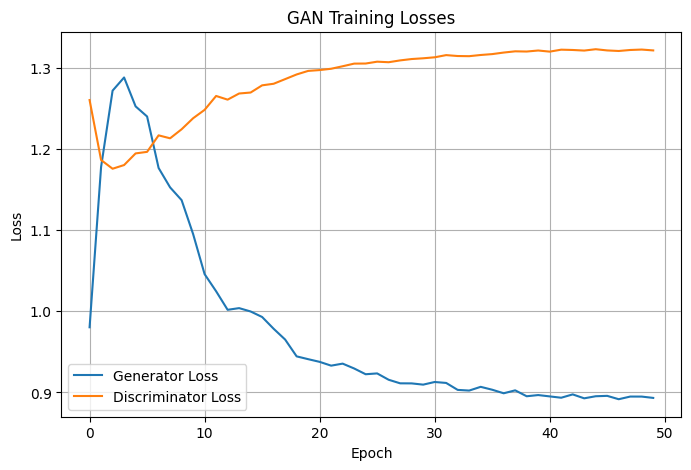

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

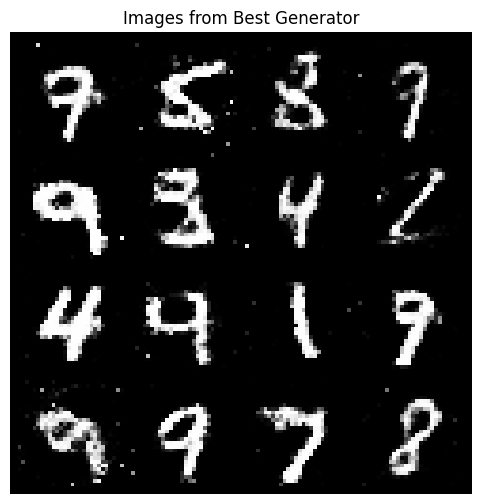

In [ ]:
# load best generator
best_generator = Generator().to(device)
best_generator.load_state_dict(torch.load(f"{rollnumber}_gen.pth", map_location=device))
best_generator.eval()

# generate some images
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    fake_imgs = best_generator(z).view(-1, 1, 28, 28)

# denormalize for display
grid = vutils.make_grid(fake_imgs, nrow=4, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.cpu(), (1, 2, 0)))
plt.title("Images from Best Generator")
plt.axis('off')
plt.show()

### Latent space interpolation with MNIST
The latent space is the space of all possible inputs that the generator can take, and it is a vector space, and since it is a vector space we can do some vector operations on it, such as interpolation, which is what we will be doing here.
To read up more on this, you can visit the following link: https://machinelearningmastery.com/how-to-interpolate-and-perform-vector-arithmetic-with-faces-using-a-generative-adversarial-network/


Things to do:
1. Define two random noises of some latent dimensions.
2. Generate images by interpolating from one noise to the other. You can use the following formula as a reference:  
   
   $$
   \text{interpolation} = \alpha \cdot z_1 + (1-\alpha) \cdot z_2
   $$  

   where  $z_{1}$ and $z_{2}$ are two random noises in the latent space. the result here should be a series of images that show how the generator is transitioning from one image to another; such as, how it goes from an image of 3 to an image of 7 for example.

3. Visualize/plot the interpolated generation.

(please make sure that there are atleast 10 steps, including the final and starting images and you visualize all 10 steps)


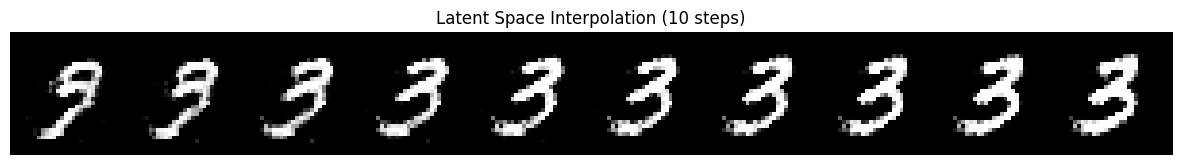

In [ ]:
def interpolate_latent(z1, z2, steps=10):
    alphas = torch.linspace(0, 1, steps).to(device)
    interpolated = []
    for alpha in alphas:
        z = alpha * z1 + (1 - alpha) * z2
        interpolated.append(z)
    return torch.cat(interpolated, dim=0)

best_generator.eval()

with torch.no_grad():
    z1 = torch.randn(1, latent_dim).to(device)
    z2 = torch.randn(1, latent_dim).to(device)

    z_interp = interpolate_latent(z1, z2, steps=10)
    generated_interp = best_generator(z_interp).view(-1, 1, 28, 28)

grid = vutils.make_grid(generated_interp, nrow=10, normalize=True)

plt.figure(figsize=(15, 2))
plt.imshow(np.transpose(grid.cpu(), (1, 2, 0)))
plt.title("Latent Space Interpolation (10 steps)")
plt.axis('off')
plt.show()

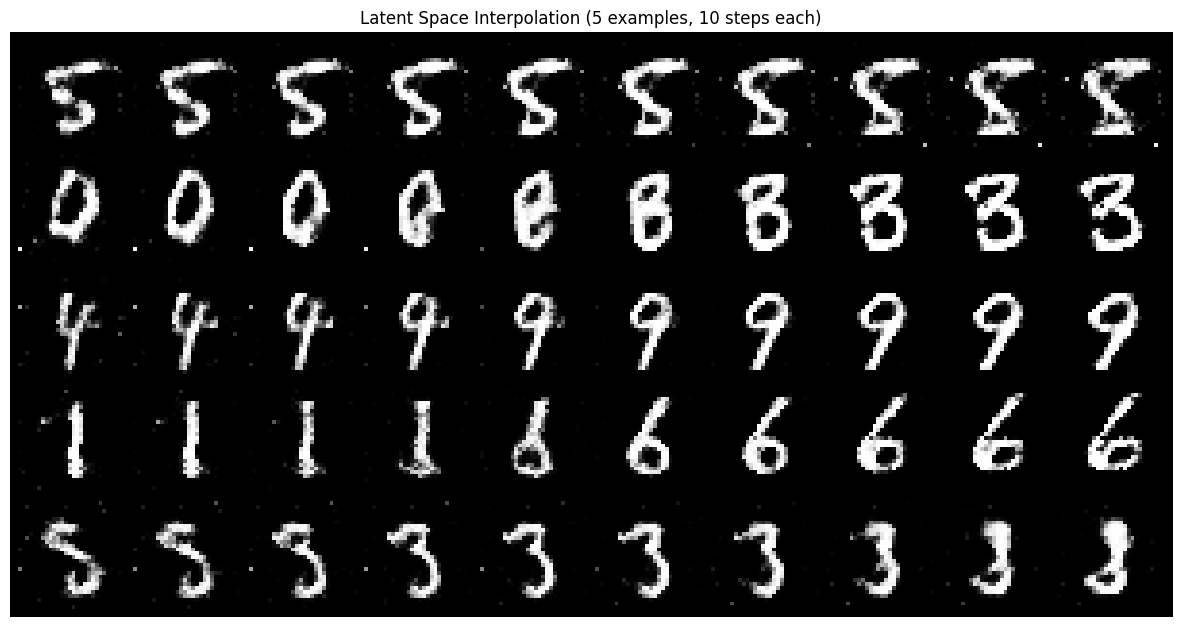

In [ ]:
def interpolate_latent(z1, z2, steps=10):
    alphas = torch.linspace(0, 1, steps).to(device)
    interpolated = []
    for alpha in alphas:
        z = alpha * z1 + (1 - alpha) * z2
        interpolated.append(z)
    return torch.cat(interpolated, dim=0)

best_generator.eval()

num_examples = 5   # number of different interpolation examples
steps = 10         # number of steps in each interpolation

all_rows = []

with torch.no_grad():
    for _ in range(num_examples):
        z1 = torch.randn(1, latent_dim).to(device)
        z2 = torch.randn(1, latent_dim).to(device)

        z_interp = interpolate_latent(z1, z2, steps=steps)
        generated_interp = best_generator(z_interp).view(-1, 1, 28, 28)

        all_rows.append(generated_interp)

# combine all rows into one big tensor
all_rows = torch.cat(all_rows, dim=0)

# show as grid: 5 rows × 10 columns
grid = vutils.make_grid(all_rows, nrow=steps, normalize=True, padding=2)

plt.figure(figsize=(15, 8))
plt.imshow(np.transpose(grid.cpu(), (1, 2, 0)))
plt.title(f"Latent Space Interpolation ({num_examples} examples, {steps} steps each)")
plt.axis("off")
plt.show()

### Latent space interpolation with pre-trained CelebA
`CelebA` dataset contains ~200,000 images of 178×218 consisting of celebrity faces. Luckily, you don't have to train your GAN over this cuz we're providing you with the pretrained model (and template code to load it). You can download the pre-trained generator from [here](https://pern-my.sharepoint.com/:f:/g/personal/24100238_lums_edu_pk/Eumg8ej04zBJigkuymRYz9MBFRscbETu-NzdzA6tsvYQPQ?e=50uaWN). There's also a `dcgan.py` file (that you're supposed to put in the current directory).

In this section, you're supposed to perform latent space interpolation just like you did with MNIST. Your  output should look smth like this:
![image.png](attachment:image.png)
(a smiling woman interpolated to a neutral man)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dcgan.py to dcgan.py
Saving generator.pt to generator.pt


In [ ]:
# put the dcgan.py file and generator.pt in the current directory and then run this cell
from dcgan import DCGAN
generator_path = "generator.pt"
gan = DCGAN(gan_type="gan", use_cuda=True)
gan.load_model(filename=generator_path, use_cuda=torch.cuda.is_available())
gan.eval()
gan = gan.to(device)
print("Number of parameters in the pre-trained generator:", gan.get_num_params())
# gan = gan.cuda()  # Move to GPU if available

Loading generator checkpoint from: generator.pt
Number of parameters in the pre-trained generator: 3592064


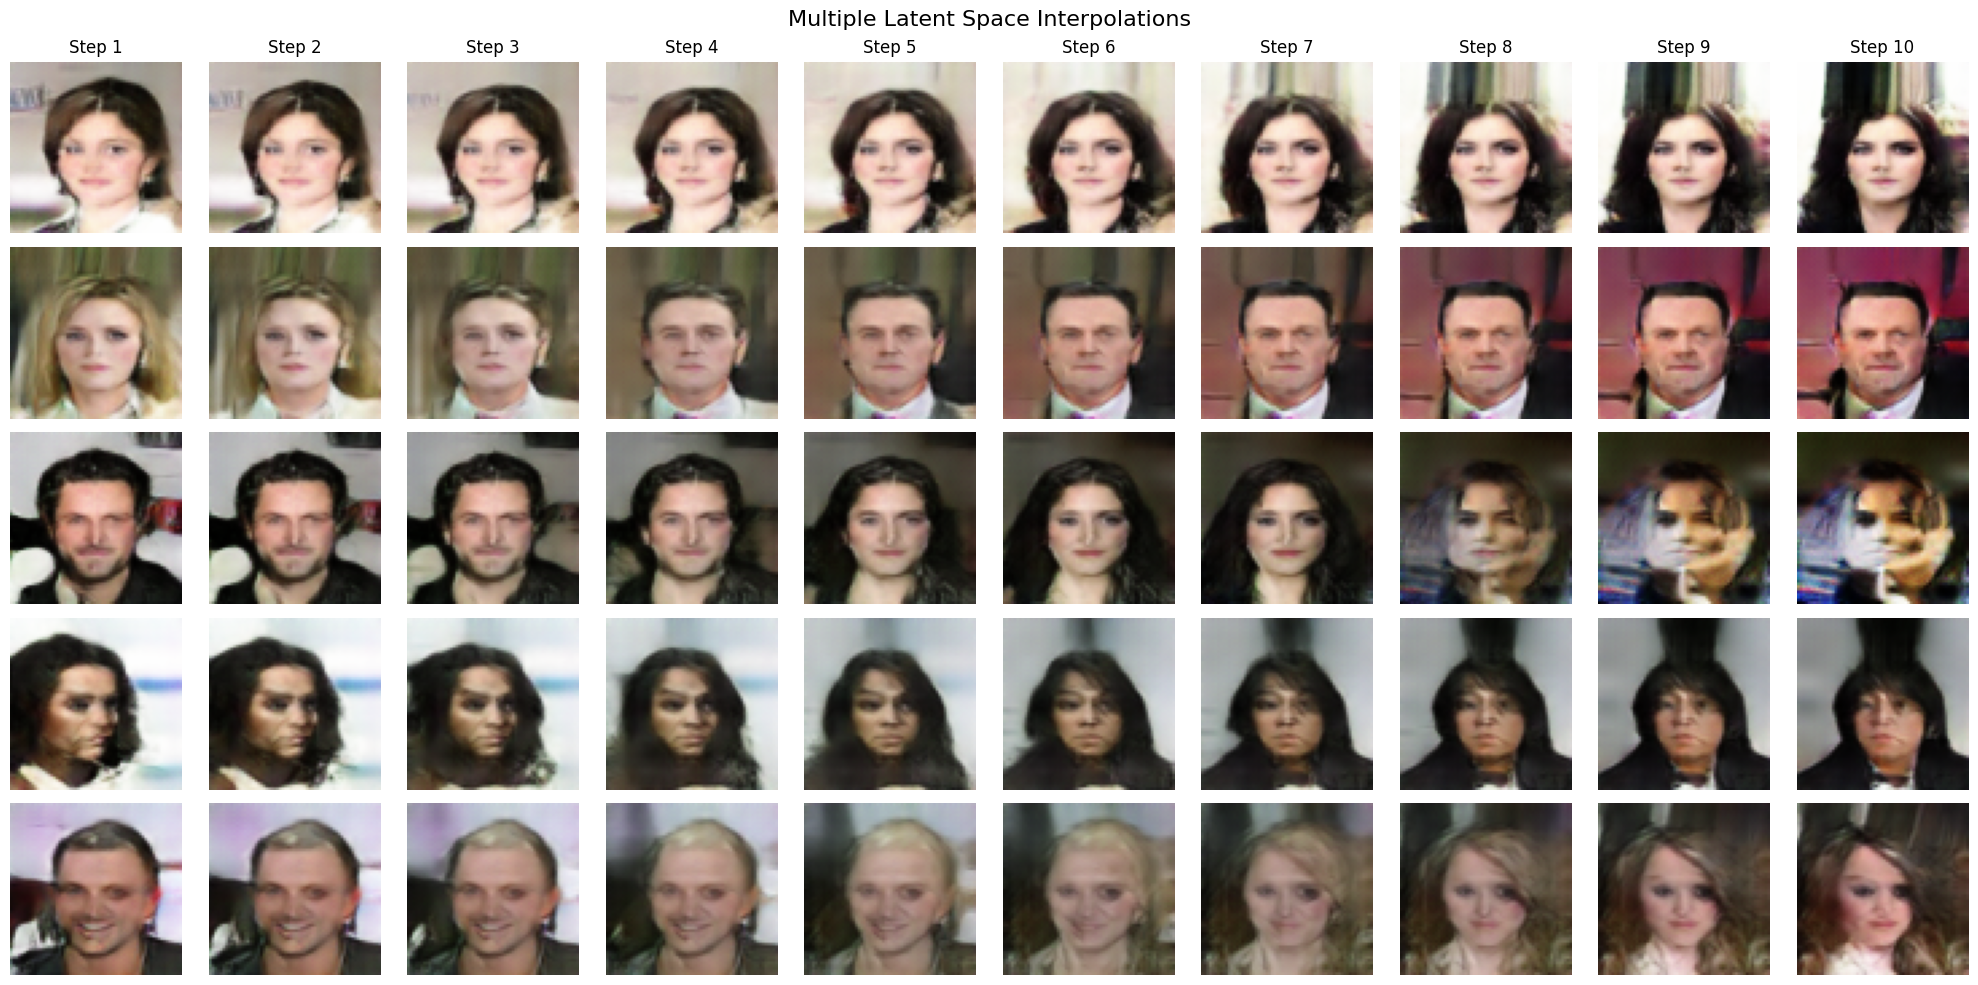

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

z_dim = gan.z_dim if hasattr(gan, "z_dim") else 100

def interpolate_latent(z1, z2, steps=10):
    alphas = torch.linspace(0, 1, steps).to(device)
    interpolated = []
    for alpha in alphas:
        z = alpha * z1 + (1 - alpha) * z2
        interpolated.append(z)
    return torch.cat(interpolated, dim=0)

num_examples = 5   # how many different interpolations you want
steps = 10         # images per interpolation

fig, axes = plt.subplots(num_examples, steps, figsize=(2 * steps, 2 * num_examples))

with torch.no_grad():
    for row in range(num_examples):
        z1 = torch.randn(1, z_dim).to(device)
        z2 = torch.randn(1, z_dim).to(device)

        z_interp = interpolate_latent(z1, z2, steps=steps)
        imgs = gan.G(z_interp)   # use gan.G, not gan()

        for col in range(steps):
            img = imgs[col].detach().cpu()
            img = (img + 1) / 2   # denormalize from [-1,1] to [0,1]
            img = np.transpose(img.numpy(), (1, 2, 0))
            img = np.clip(img, 0, 1)

            axes[row, col].imshow(img)
            axes[row, col].axis("off")

            if row == 0:
                axes[row, col].set_title(f"Step {col+1}")

plt.suptitle("Multiple Latent Space Interpolations", fontsize=16)
plt.tight_layout()
plt.show()

### Vector arithmatic in the latent space
Since issa vector space, you can perform arithmatics (such as subtraciton, addition etc.)
<br>

When interpolating between two celebA images in the latent space, you might notice that the transition sometimes passes through representations of other facial expressions/genders. If you see the example above, while morphing from a smiling woman to a neutral man, the image briefly resembles a neutral woman. This happens because the latent space captures underlying features of the dataset, and the interpolation path can traverse regions where features of both numbers mix.

This concept extends to arithmetic in the latent space—adding/subtracting two (or more) latent vectors can produce meaningful blends of their features. For instance, adding the representation of a black person and a white person might generate a brown person.

Now, in this section, you're supposed to perform the following tasks:
1. Generate two (or more) images.
2. Perform some arithmetic on their latent space vectors and then generate the image from the resultant.
3. Display the results. <br>

### Example:
1.  $\text{random\_noise}_1$  generates $\text{generated\_image}_1$, and  
   $\text{random\_noise}_2$ generates $\text{generated\_image}_2$.
   You can save your noises as `.pt` file using `torch.save()`.
2. Compute the new latent vector:  
   $\text{random\_noise}_r$ = $\text{random\_noise}_1$ + $\text{random\_noise}_2$
3. Generate an image from $\text{random\_noise}_r$, denoted as $\text{generated\_image}_r$.
4. Display the results and check if:  
   $\text{generated\_image}_r$ = $\text{generated\_image}_1$ + $\text{generated\_image}_2$

Repeat this for at least three different pairs of images (with diff arithmetics).

Note: the arithematic results won't be perfect but to some extent would make sense.

Pair 1 arithmetic: zr = z1 + z2


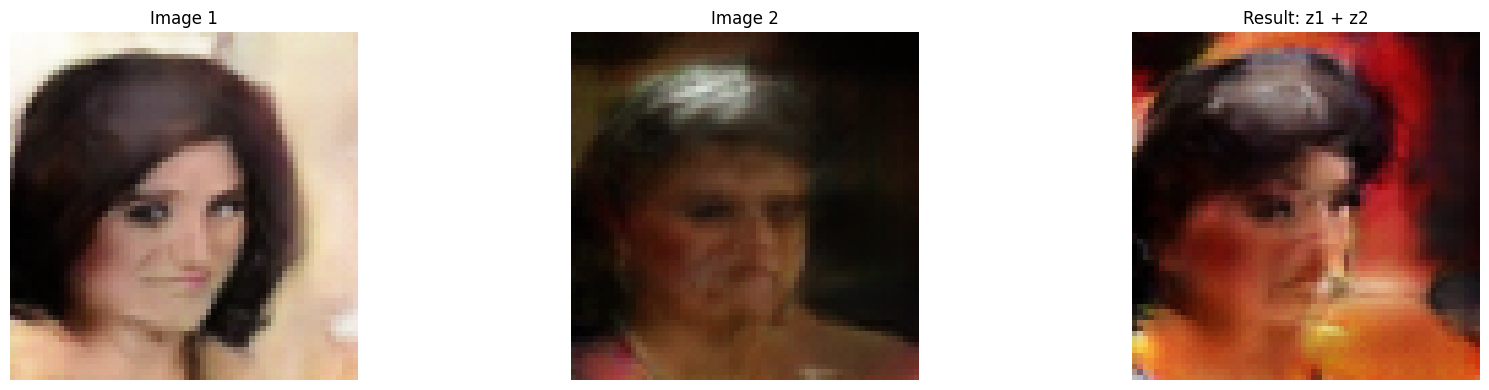

In [ ]:
# display random images from the generator, then dispaly there arithmetic.
# get latent dimension
z_dim = gan.z_dim if hasattr(gan, "z_dim") else 100

# helper to generate image from latent vector
def generate_from_z(z):
    with torch.no_grad():
        img = gan.G(z)
    return img

# helper to show a row of images
def show_images(imgs, titles, figsize=(18, 4)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)

    if len(imgs) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, imgs, titles):
        img_np = img.detach().cpu().squeeze(0)
        img_np = (img_np + 1) / 2   # convert from [-1,1] to [0,1] if needed
        img_np = img_np.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)

        ax.imshow(img_np)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# =========================
# Pair 1: Addition
# zr = z1 + z2
# =========================
z1 = torch.randn(1, z_dim).to(device)
z2 = torch.randn(1, z_dim).to(device)
zr1 = z1 + z2

# save latent vectors
torch.save(z1.cpu(), "noise_pair1_z1.pt")
torch.save(z2.cpu(), "noise_pair1_z2.pt")
torch.save(zr1.cpu(), "noise_pair1_result.pt")

img1 = generate_from_z(z1)
img2 = generate_from_z(z2)
img_r1 = generate_from_z(zr1)

print("Pair 1 arithmetic: zr = z1 + z2")
show_images(
    [img1, img2, img_r1],
    ["Image 1", "Image 2", "Result: z1 + z2"]
)

Pair 2 arithmetic: zr = (z3 + z4) / 2


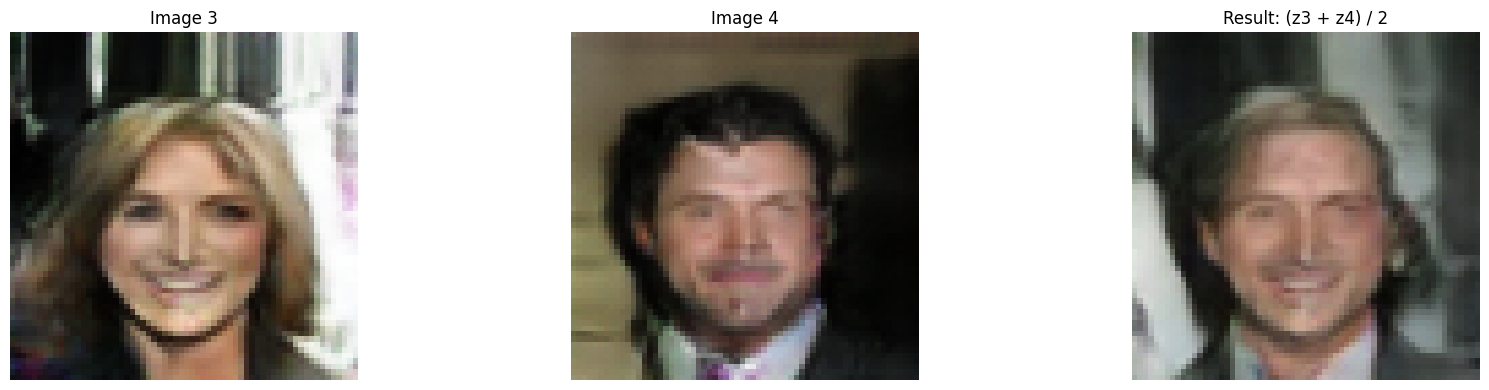

In [ ]:
# display random images from the generator, then dispaly there arithmetic.
# =========================
# Pair 2: Average / Blend
# zr = (z3 + z4) / 2
# =========================
z3 = torch.randn(1, z_dim).to(device)
z4 = torch.randn(1, z_dim).to(device)
zr2 = (z3 + z4) / 2

torch.save(z3.cpu(), "noise_pair2_z3.pt")
torch.save(z4.cpu(), "noise_pair2_z4.pt")
torch.save(zr2.cpu(), "noise_pair2_result.pt")

img3 = generate_from_z(z3)
img4 = generate_from_z(z4)
img_r2 = generate_from_z(zr2)

print("Pair 2 arithmetic: zr = (z3 + z4) / 2")
show_images(
    [img3, img4, img_r2],
    ["Image 3", "Image 4", "Result: (z3 + z4) / 2"]
)

Pair 3 arithmetic: zr = z5 + z6 - z7


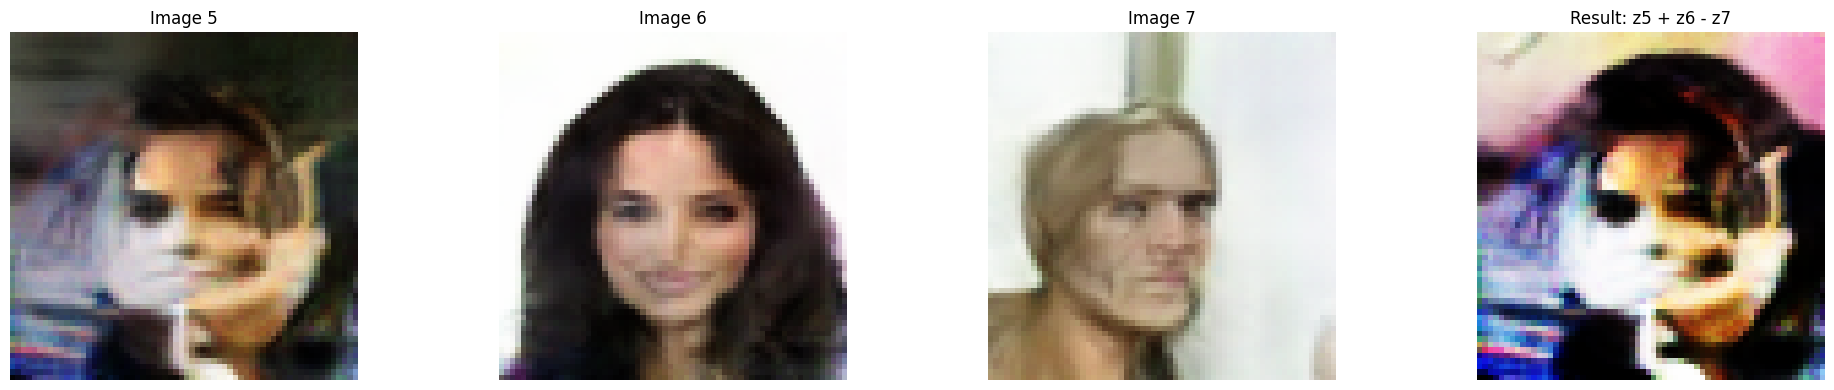

In [ ]:
# display random images from the generator, then dispaly there arithmetic.
# =========================
# Pair 3: Add and Subtract
# zr = z5 + z6 - z7
# =========================
z5 = torch.randn(1, z_dim).to(device)
z6 = torch.randn(1, z_dim).to(device)
z7 = torch.randn(1, z_dim).to(device)
zr3 = z5 + z6 - z7

torch.save(z5.cpu(), "noise_pair3_z5.pt")
torch.save(z6.cpu(), "noise_pair3_z6.pt")
torch.save(z7.cpu(), "noise_pair3_z7.pt")
torch.save(zr3.cpu(), "noise_pair3_result.pt")

img5 = generate_from_z(z5)
img6 = generate_from_z(z6)
img7 = generate_from_z(z7)
img_r3 = generate_from_z(zr3)

print("Pair 3 arithmetic: zr = z5 + z6 - z7")
show_images(
    [img5, img6, img7, img_r3],
    ["Image 5", "Image 6", "Image 7", "Result: z5 + z6 - z7"],
    figsize=(20, 4)
)

## ANALYTICAL QUESTIONS

**Q1:** You see some of the generated images are distorted or sorta unrealistic. What major problem do you think GANs have that's causing this distortion? <br><br>
**Ans** (keep it very brief and preferably make bullet points):

You may have look over [here](https://aurorasolar.com/blog/putting-ai-to-the-test-generative-adversarial-networks-vs-diffusion-models/) how diffusion models intriduced realism in the image generations (as compared to the GANs)

## Comparison Question 1: Image Quality vs Latent Representation

Across the assignments you worked with three generative setups:

- **β-VAE trained on the CelebA dataset**
- **GAN trained on the MNIST dataset**
- **Pre-trained GAN on the CelebA dataset**

Compare the results produced by these models.

Discuss the following:

- Which model produced the **most visually realistic images**?
- Which model had the **most interpretable latent space**?
- Why do **GANs generally produce sharper images** compared to VAEs?
- Why are **β-VAEs better for understanding latent features**?

Use examples from your **MNIST generations, CelebA interpolations, and β-VAE latent traversals**.

**Answer (Max 120 Words):**

* **Most realistic images:** Pre-trained CelebA GAN produced the most realistic faces; MNIST GAN generated clear digits but simpler; β-VAE outputs were blurrier.
* **Most interpretable latent space:** β-VAE had the most interpretable latent space. Latent traversals showed clear control over features (e.g., face orientation, brightness), unlike GANs.
* **Why GANs are sharper:** GANs use adversarial loss, directly pushing outputs toward realistic, high-frequency details, while VAEs optimize reconstruction likelihood, leading to averaging and blur.
* **Why β-VAEs are better for latent understanding:** The β term enforces disentanglement, separating features into independent factors, making latent dimensions meaningful and easier to interpret.


## Comparison Question 2: Latent Space Behavior

In the assignments you explored **latent space operations** in two different ways:

- In the **β-VAE**, you varied individual latent dimensions to observe how specific features of CelebA faces changed.
- In the **GAN experiments**, you performed **latent interpolation and vector arithmetic** between latent vectors for MNIST digits and CelebA faces.

Compare how the latent space behaved in these models.

Discuss:

- How **changing a single latent dimension in the β-VAE** affected generated faces.
- How **interpolating between two latent vectors in GANs** affected generated digits/faces.
- Which model showed **clearer control over specific visual attributes**.
- Which model produced **smoother transitions during interpolation**.

Explain your observations using examples from the visualizations you generated.

**Answer (Max 120 Words):**

* **β-VAE latent changes:** Changing one latent dimension led to controlled, gradual changes in specific features like face orientation, brightness, or hair style. Each dimension affected a distinct attribute, showing good disentanglement.
* **GAN interpolation:** Interpolating between two latent vectors produced smooth transitions, such as one digit morphing into another or faces blending identity and expression, but multiple features changed together.
* **Clearer control:** β-VAE showed clearer control over individual visual attributes due to its disentangled latent space.
* **Smoother transitions:** GANs produced smoother and more realistic transitions during interpolation, especially in CelebA, as seen in continuous morphing between faces.
